In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ncmcm.data_loaders.matlab_dataset import Database
from ncmcm.visualisers.latent_space import LatentSpaceVisualiser

import os
os.chdir("../..")
os.getcwd()

'/home/akshey/Desktop/PhD/Code_repositories/bundlenet_results'

# Time aligning the behaviours
We extract behavioural bouts, defined as contiguous segments in which the animal expresses a given behaviour. For each bout, we record its indices in time as well as the behaviours immediately preceding and following it. We plot them in normalised time. Later we will interpolate these bouts so they have the same number of time points.


In [2]:

def extract_bouts(B, b):
    bouts = []
    current_bout = []

    for i, val in enumerate(B):
        if val == b:
            current_bout.append(i)  # Add index to the current bout
        else:
            if current_bout:  # If the current bout is not empty, save it
                bouts.append(current_bout)
                current_bout = []  # Reset for the next bout

    if current_bout:  # Append the last bout if the B ends with a bout
        bouts.append(current_bout)

    bout_indices = sorted(bouts, key=len)
    next_b = [B[idx[-1] + 1] if idx[-1] + 1 < len(B) else None for idx in bout_indices]
    prev_b = [B[idx[0] - 1] if idx[0] - 1 >= 0 else None for idx in bout_indices]

    return bout_indices, np.array(next_b), np.array(prev_b)


def plot_behaviours_in_normalised_time(Y, B, b, behaviour_name):
    # extracting behavioural bouts
    bout_indices, _, _ = extract_bouts(B, b)
    Y_bouts = [Y[idx] for idx in bout_indices]

    # plotting
    # cmap = plt.get_cmap('tab10')
    colors = ["#008080", "#FF6F61", "#FFD700"]
    # plt.figure(figsize=(3.5, 3))
    plt.figure(figsize=(10, 7))

    for bout_idx, y_bout in enumerate(Y_bouts):
        normalised_t = np.linspace(0, 1, y_bout.shape[0])
        for i in range(3):
            darkness_factor = 0.3 + 0.7 * (bout_idx / len(Y_bouts))
            # color = cmap(i)
            # plt.plot(normalised_t, y_bout[:, i], c=colors[i], alpha=darkness_factor, marker='o')
            plt.plot(normalised_t, y_bout[:, i], c=colors[i], alpha=darkness_factor, marker='o')

    plt.xlabel('normalized time', fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks([])
    plt.title(f"Behaviour : {behaviour_name}", fontsize=20)
    plt.tight_layout()
    plt.savefig(f'c_elegans_results/time_alignment/figures/time_aligned_latent_dynamics_behaviour_{behaviour_name}.pdf')



BunDLeNet  worm_num:  0


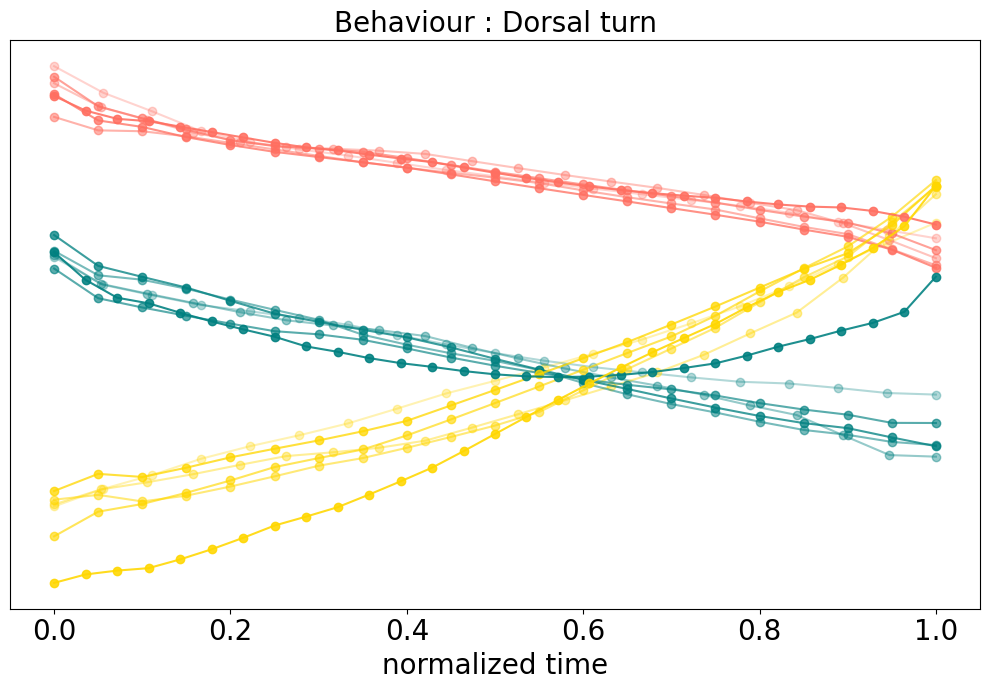

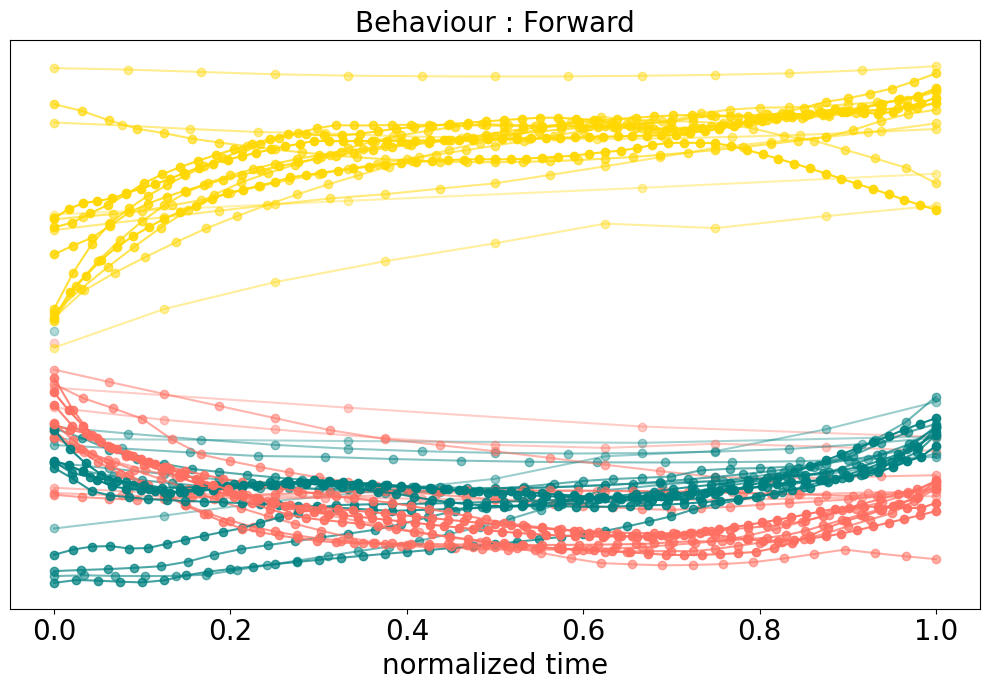

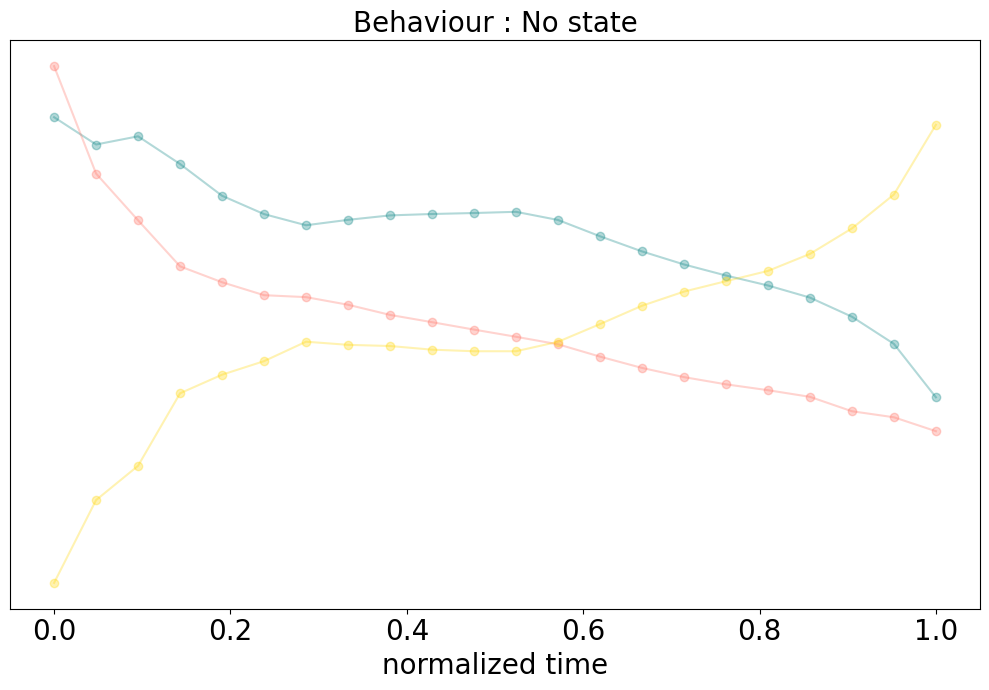

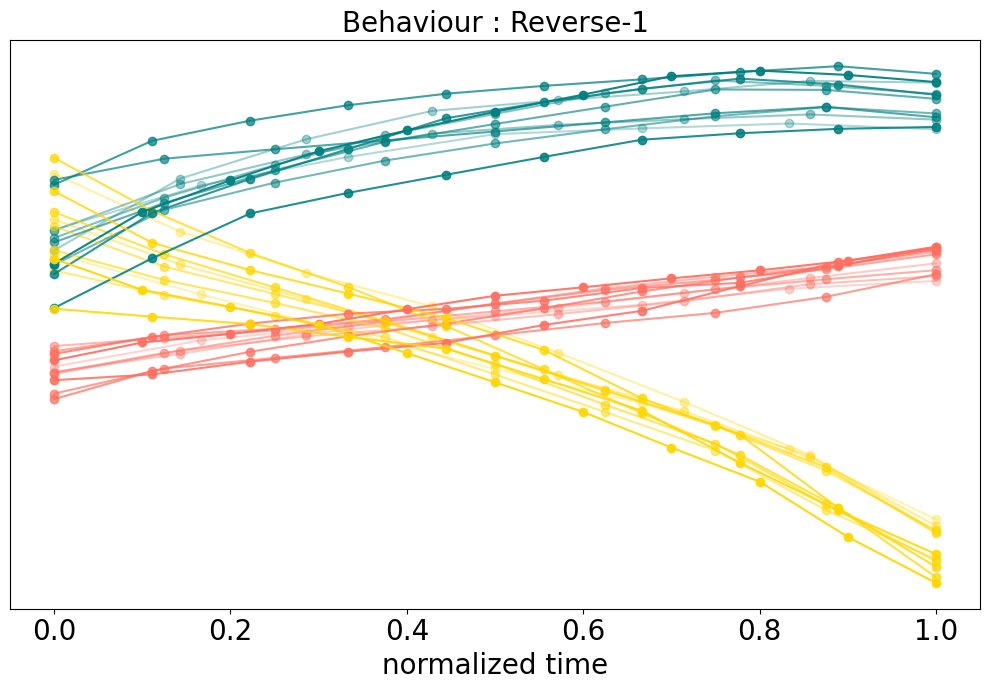

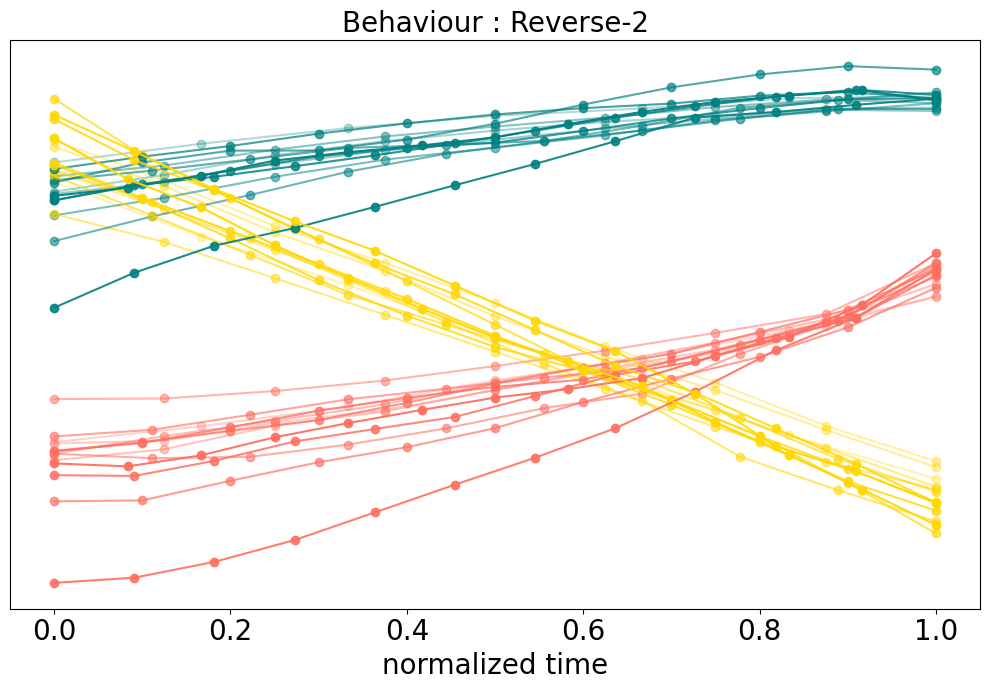

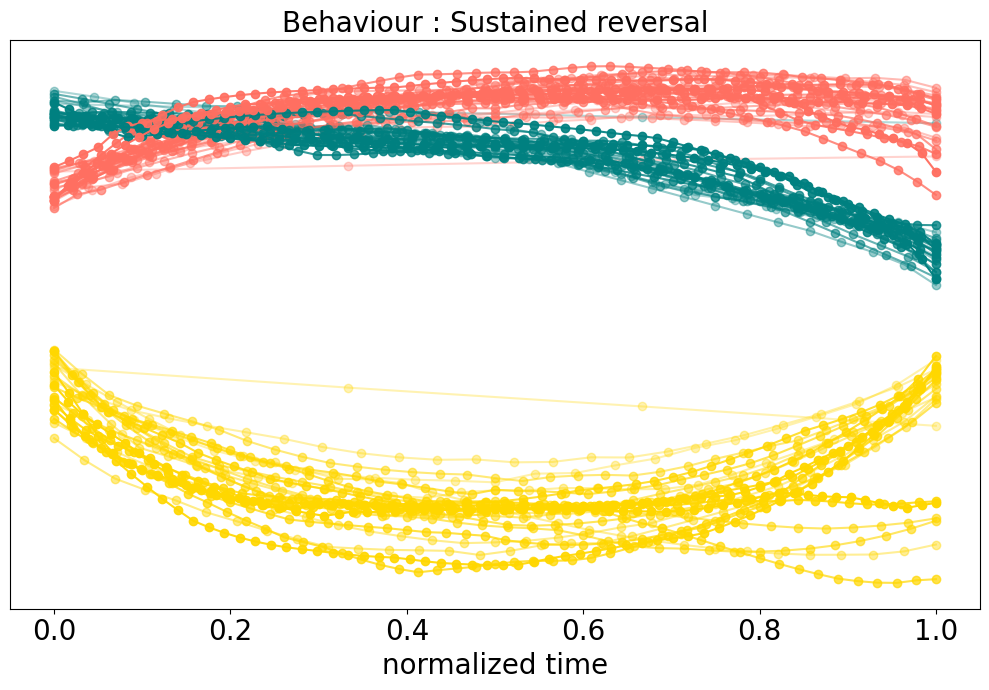

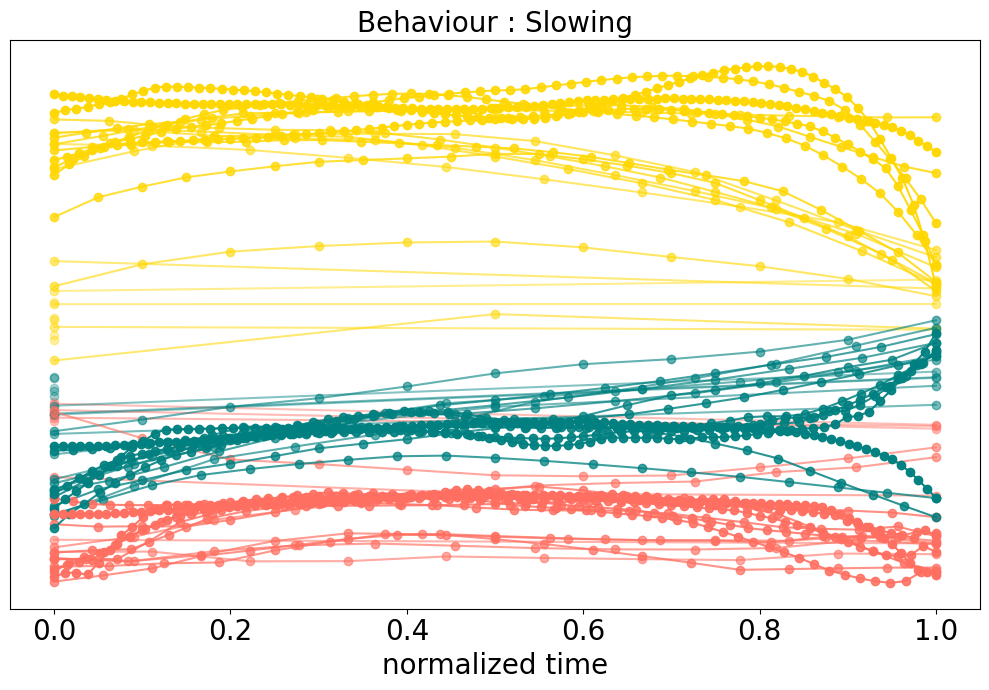

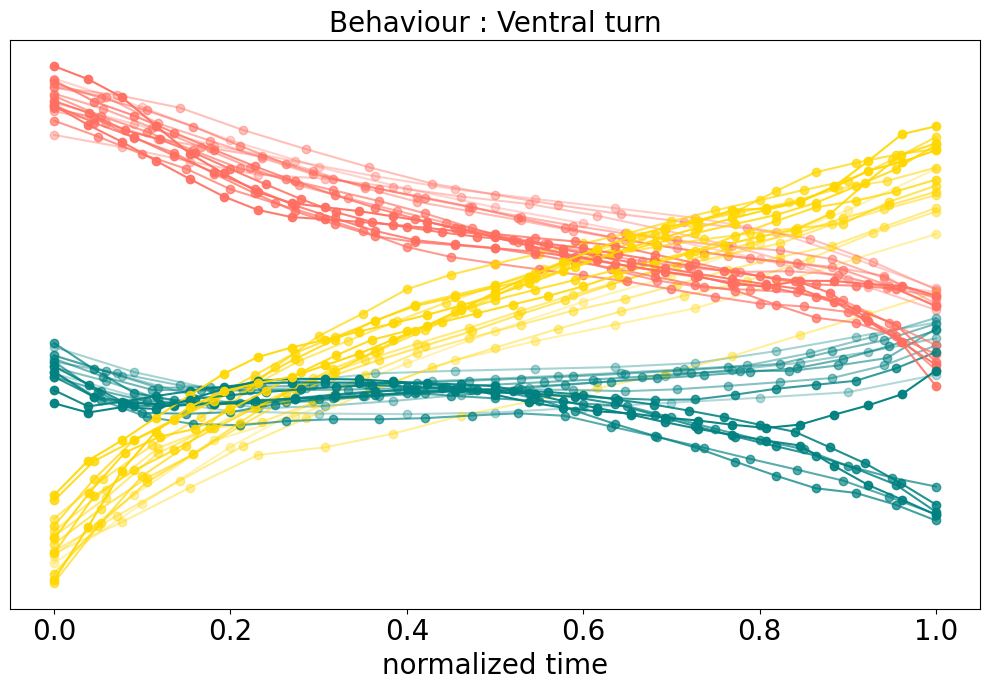

In [3]:
algorithm = 'BunDLeNet'
worm_num = 0
print(algorithm, ' worm_num: ', worm_num)

data_path = 'data/raw/c_elegans/NoStim_Data.mat'
data = Database(data_path=data_path, dataset_no=worm_num)

file_pattern = f'data/generated/embeddings/c_elegans/{{}}__{algorithm}_worm_{worm_num}'
y0_tr = np.loadtxt(file_pattern.format('Y0_tr'))
y1_tr = np.loadtxt(file_pattern.format('Y1_tr'))
y0_tst = np.loadtxt(file_pattern.format('Y0_tst'))
y1_tst = np.loadtxt(file_pattern.format('Y1_tst'))
b_train_1 = np.loadtxt(file_pattern.format('B_train_1')).astype(int)
b_test_1 = np.loadtxt(file_pattern.format('B_test_1')).astype(int)

for b in np.unique(b_train_1):
    plot_behaviours_in_normalised_time(y1_tr, b_train_1, b, data.behaviour_names[b])
plt.show()

# From latent branching trajectories to the underlying neural activity
We first trained an inverse embedder network to map latent trajectories back into neural activity space using paired training and test data. Once trained, this model allowed us to probe how specific points in latent space correspond to underlying neural patterns.

To study sustained reversal behaviour, we extracted all bouts of this class from the training set. Each bout was interpolated to a fixed number of time steps, giving a time-normalized representation of the latent dynamics across bouts. We then grouped bouts based on their transition structure, identifying conditions such as the behaviour that preceded or followed the reversal.

From these interpolated trajectories, we computed representative latent states at key moments: the start of the reversal (conditioned on different preceding behaviours), the middle of the reversal, and the end of the reversal (conditioned on different following behaviours). Averaging across bouts gave a set of prototypical latent states that capture common dynamics of the behaviour.

Finally, we passed these representative latent states through the inverse embedder to reconstruct the corresponding neural population activity. The reconstructed activity patterns were plotted to visualise how distinct phases of a sustained reversal map back to neural activity, providing an interpretable link between dynamics in the learned latent space and observable neural signals.

In [4]:
from c_elegans_results.time_alignment.inverse_embedding import fit_inverse_embedder 
from c_elegans_results.time_alignment.interpolation import interpolate_bouts
from c_elegans_results.time_alignment.time_alignment import extract_bouts
from ncmcm.bundlenet.utils import prep_data, timeseries_train_test_split


/home/akshey/Desktop/PhD/Code_repositories/comparison-algorithms/.env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-08-27 16:03:18,331	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-08-27 16:03:19.753755: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-27 16:03:19.753778: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-27 16:03:19.754866: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to re

In [5]:
data_path = 'data/raw/c_elegans/NoStim_Data.mat'
data = Database(data_path=data_path, dataset_no=worm_num)
b_neurons = [
    'AVAR',
    'AVAL',
    'SMDVR',
    'SMDVL',
    'SMDDR',
    'SMDDL',
    'RIBR',
    'RIBL', ]
data.exclude_neurons(b_neurons)
x = data.neuron_traces.T
b = data.behaviour
x_, b_ = prep_data(x, b, win=15)
x_train, x_test, _, _ = timeseries_train_test_split(x_, b_)
x0_tr = x_train[:, 0, -1, :]
x0_tst = x_test[:, 0, -1, :]

# fitting inverse embedder
inverse_embedder = fit_inverse_embedder(x0_tr, y0_tr, x0_tst, y0_tst)

2.212211960268753 2.7698171138763428 -0.013133410249483057 -3.4226813316345215
(2676, 3) (2676, 103)


2025-08-27 16:03:21.375490: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-08-27 16:03:21.376536: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## analysis for sustatined reversal behaviour

In [21]:
# points to inverse embed (sustained reversal)
bout_indices, next_b, prev_b = extract_bouts(b_train_1, 5)
y_bouts = [y0_tr[idx] for idx in bout_indices]
y_bouts = interpolate_bouts(y_bouts, t_steps_interp=21)
for i in range(8):
    print(i, y_bouts[next_b==i].shape)


y0_inv_embed = []

y0_inv_embed.append(y_bouts[prev_b==3][:,:,0].mean(axis=0))
y0_inv_embed.append(y_bouts[prev_b==4][:,:,0].mean(axis=0))
y0_inv_embed.append(y_bouts[:,:,10].mean(axis=0))
y0_inv_embed.append(y_bouts[next_b==0][:,:,20].mean(axis=0))
y0_inv_embed.append(y_bouts[next_b==7][:,:,20].mean(axis=0))
y0_inv_embed = np.array(y0_inv_embed)
print(y0_inv_embed)



0 (6, 3, 21)
1 (0, 3, 21)
2 (1, 3, 21)
3 (0, 3, 21)
4 (0, 3, 21)
5 (0, 3, 21)
6 (1, 3, 21)
7 (16, 3, 21)
[[ 1.21848616  0.4266731  -1.02743208]
 [ 1.12734326 -0.02465527 -1.48278422]
 [ 0.85006496  1.20807021 -2.69096573]
 [-0.30526856  0.88625428 -2.93013755]
 [-0.08219662  1.22524277 -1.65288474]]


<IPython.core.display.Javascript object>


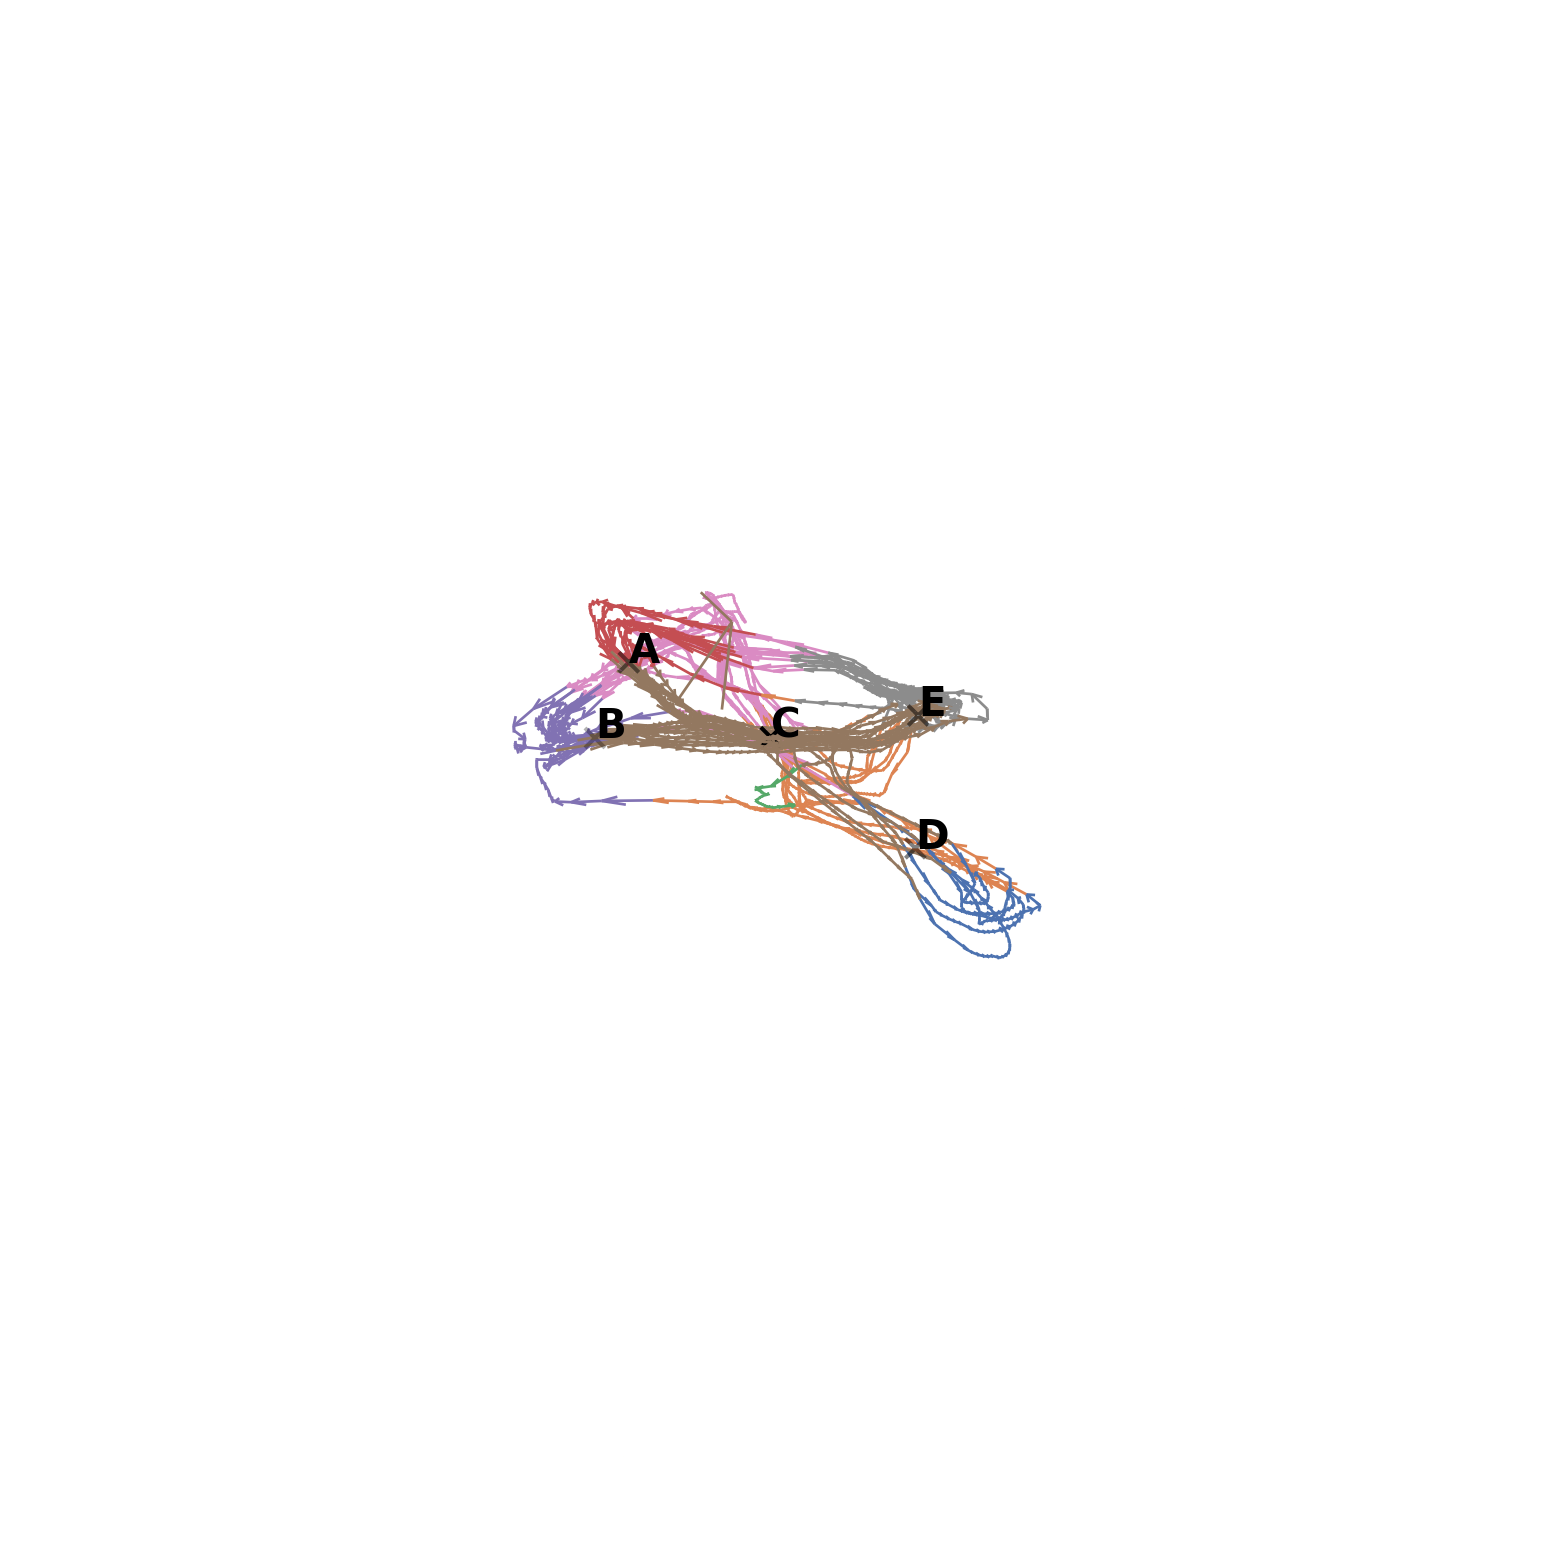

In [22]:
%matplotlib notebook
vis = LatentSpaceVisualiser(y0_tr, b_train_1, data.behaviour_names, legend=False)
fig, ax = vis.plot_phase_space(axis_view=(-32, 55,), arrow_length_ratio=0.4, show_fig=False)
ax.scatter(y0_inv_embed[:, 0], y0_inv_embed[:, 1], y0_inv_embed[:, 2], 
           c='k', s=55, marker='x')

if True:
    # Define labels for each representative point
    point_labels = ["A", "B", "C", "D", "E"]
    for i, point_label in enumerate(point_labels):
        ax.text(y0_inv_embed[i, 0],  y0_inv_embed[i, 1],  y0_inv_embed[i, 2], point_label, fontsize=15, fontweight='bold', zorder=10000)


plt.show()

(5, 103)


<IPython.core.display.Javascript object>


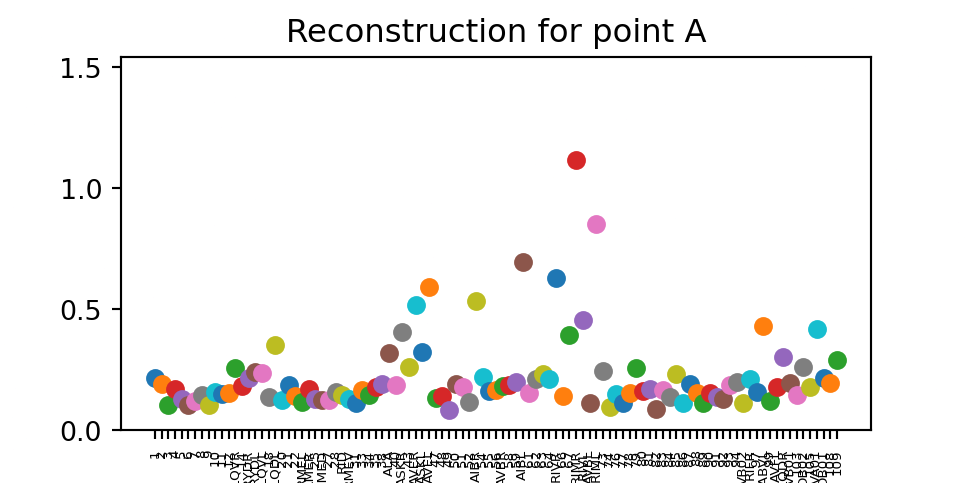

<IPython.core.display.Javascript object>


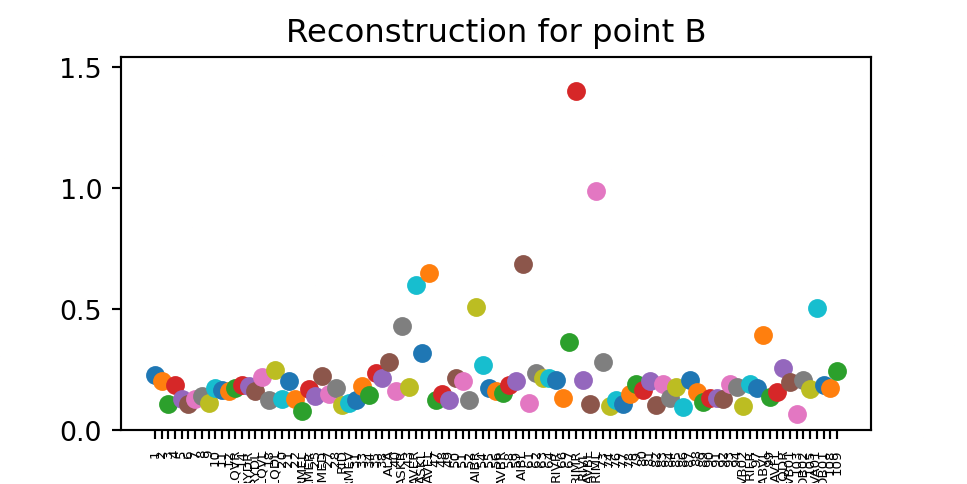

<IPython.core.display.Javascript object>


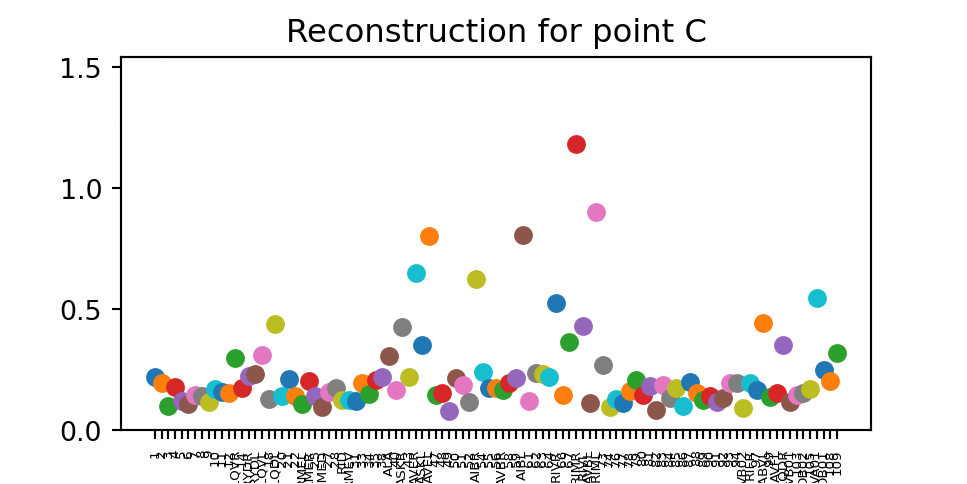

<IPython.core.display.Javascript object>


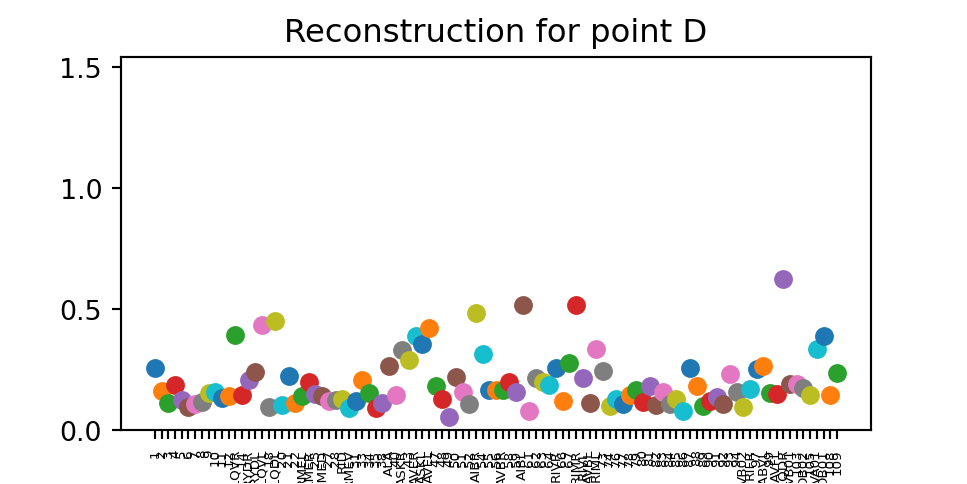

<IPython.core.display.Javascript object>


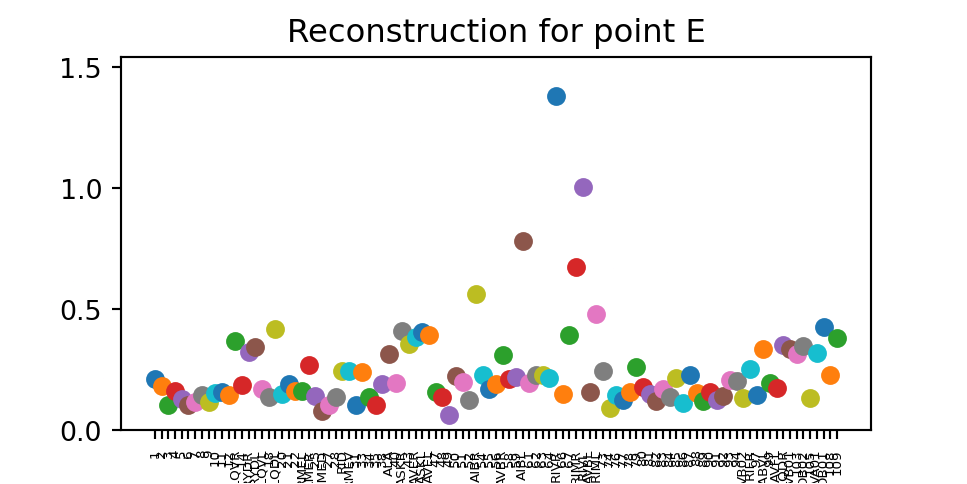

In [24]:

# Inverse-embed representative points
x0_pred = inverse_embedder(y0_inv_embed).numpy()
print(x0_pred.shape)

# Plot reconstructed neural activity for each labeled point
for i, (x_i, label) in enumerate(zip(x0_pred, point_labels)):
    plt.figure(figsize=(5, 2.5))
    for n, x_n in enumerate(x_i):
        plt.ylim(0, 1.1 * x0_pred.max())
        plt.scatter(n, x_n)
    plt.title(f"Reconstruction for point {label}")
    plt.xticks(ticks=np.arange(len(x_i)), labels=data.neuron_names, rotation=90, fontsize=5)
    plt.show()


## analysis for ventral turn behaviour

In [25]:
# points to inverse embed(ventral turn)
bout_indices, next_b, prev_b = extract_bouts(b_train_1, 7)
print(next_b)
print(prev_b)

y_bouts = [y0_tr[idx] for idx in bout_indices]
y_bouts = interpolate_bouts(y_bouts, t_steps_interp=21)
for i in range(8):
    print(i, y_bouts[prev_b==i].shape)


y0_inv_embed = []
y0_inv_embed.append(y_bouts[:,:,0].mean(axis=0))
y0_inv_embed.append(y_bouts[:,:,10].mean(axis=0))
y0_inv_embed.append(y_bouts[next_b==1][:,:,20].mean(axis=0))
y0_inv_embed.append(y_bouts[next_b==6][:,:,20].mean(axis=0))

y0_inv_embed = np.array(y0_inv_embed)
print(y0_inv_embed)

[6 6 1 6 6 6 6 6 1 1 1 6 1 1 1 6]
[5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]
0 (0, 3, 21)
1 (0, 3, 21)
2 (0, 3, 21)
3 (0, 3, 21)
4 (0, 3, 21)
5 (16, 3, 21)
6 (0, 3, 21)
7 (0, 3, 21)
[[-0.1926661   1.17259888 -1.45954809]
 [-0.43965689  0.48015894 -0.11695206]
 [-0.86104479 -0.09813102  0.65285482]
 [-0.27333819  0.15814885  0.52409003]]


<IPython.core.display.Javascript object>


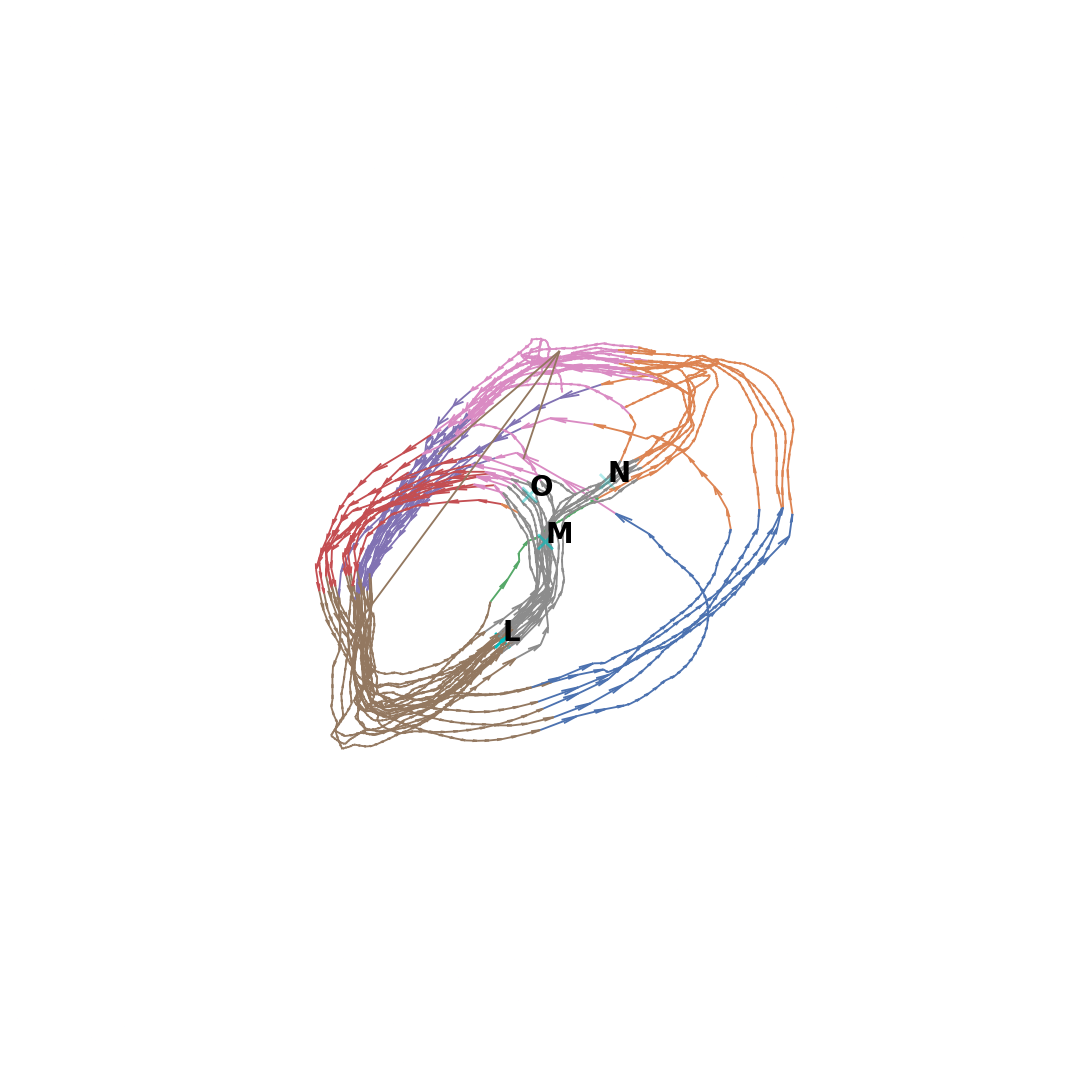

In [28]:
%matplotlib notebook
vis = LatentSpaceVisualiser(y0_tr, b_train_1, data.behaviour_names, legend=False)
fig, ax = vis.plot_phase_space(axis_view=(16, 97,), arrow_length_ratio=0.4, show_fig=False)
ax.scatter(y0_inv_embed[:, 0], y0_inv_embed[:, 1], y0_inv_embed[:, 2], 
           c='c', s=65, marker='x')

if True:
    # Define labels for each representative point
    point_labels = ["L", "M", "N", "O", ]
    for i, point_label in enumerate(point_labels):
        ax.text(y0_inv_embed[i, 0],  y0_inv_embed[i, 1],  y0_inv_embed[i, 2], point_label, fontsize=15, fontweight='bold', zorder=10000)


plt.show()

(4, 103)


<IPython.core.display.Javascript object>


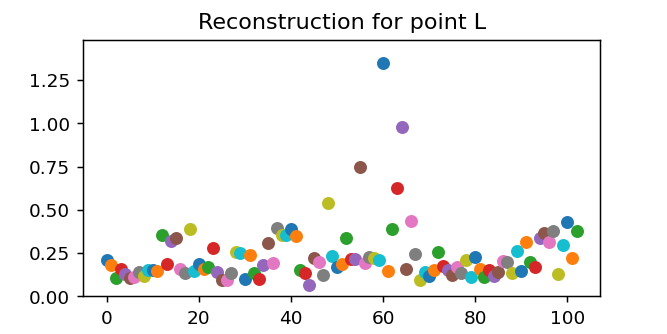

<IPython.core.display.Javascript object>


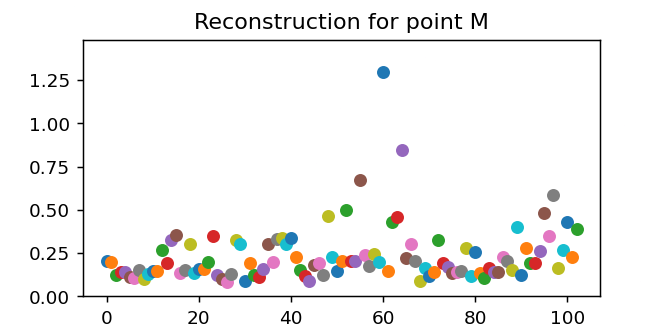

<IPython.core.display.Javascript object>


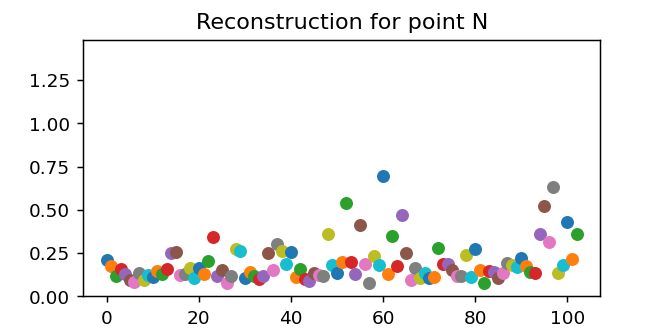

<IPython.core.display.Javascript object>


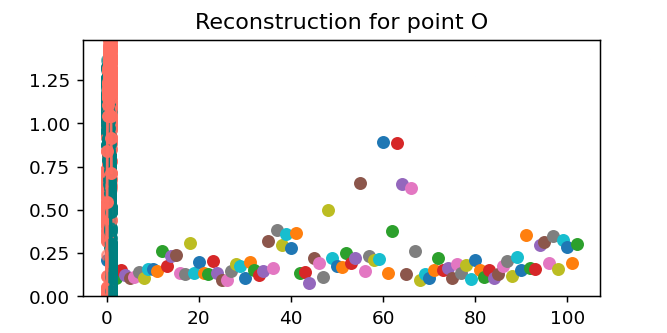

In [29]:
# Inverse-embed representative points
x0_pred = inverse_embedder(y0_inv_embed).numpy()
print(x0_pred.shape)

# Plot reconstructed neural activity for each labeled point
for i, (x_i, label) in enumerate(zip(x0_pred, point_labels)):
    plt.figure(figsize=(5, 2.5))
    for n, x_n in enumerate(x_i):
        plt.ylim(0, 1.1 * x0_pred.max())
        plt.scatter(n, x_n)
    plt.title(f"Reconstruction for point {label}")
    plt.show()


# Decoding analysis (for next behaviour)


## for sustained reversal

In [49]:
data.behaviour_names

{0: 'Dorsal turn',
 1: 'Forward',
 2: 'No state',
 3: 'Reverse-1',
 4: 'Reverse-2',
 5: 'Sustained reversal',
 6: 'Slowing',
 7: 'Ventral turn'}

/home/akshey/Desktop/PhD/Code_repositories/comparison-algorithms/.env/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/home/akshey/Desktop/PhD/Code_repositories/comparison-algorithms/.env/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/home/akshey/Desktop/PhD/Code_repositories/comparison-algorithms/.env/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/home/akshey/Desktop/PhD/Code_repositories/comparison-algorithms/.env/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


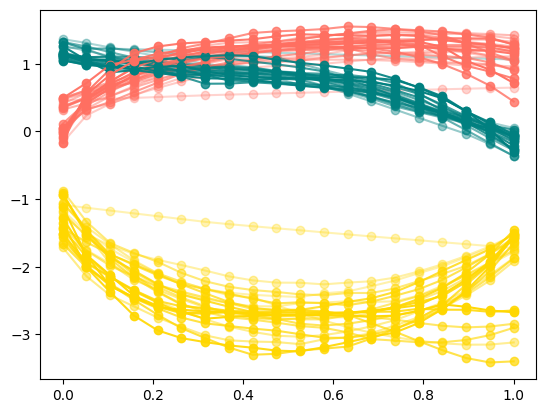

In [54]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

algorithm = 'BunDLeNet'
worm_num = 0

file_pattern = f'data/generated/embeddings/c_elegans/{{}}__{algorithm}_worm_{worm_num}'
Y0_tr = np.loadtxt(file_pattern.format('Y0_tr'))
Y1_tr = np.loadtxt(file_pattern.format('Y1_tr'))
Y0_tst = np.loadtxt(file_pattern.format('Y0_tst'))
Y1_tst = np.loadtxt(file_pattern.format('Y1_tst'))
B_train_1 = np.loadtxt(file_pattern.format('B_train_1')).astype(int)
B_test_1 = np.loadtxt(file_pattern.format('B_test_1')).astype(int)


bout_indices, next_b, _ = extract_bouts(B_train_1, b=5) #  5: 'Sustained reversal',
Y_bouts = [Y0_tr[idx] for idx in bout_indices]
Y_bouts = interpolate_bouts(Y_bouts, t_steps_interp=20, show_plot=True)

# Define the classifier
clf = LogisticRegression()
n_folds = 5
scores = np.zeros((Y_bouts.shape[2], n_folds))

for t in range(Y_bouts.shape[2]):
    Y_bout_t = Y_bouts[:, :, t]
    scores[t] = cross_val_score(clf, Y_bout_t, next_b, cv=n_folds, scoring='accuracy')

mean_scores = scores.mean(axis=1)
std_error = scores.std(axis=1) / np.sqrt(n_folds)  # Standard error of the mean


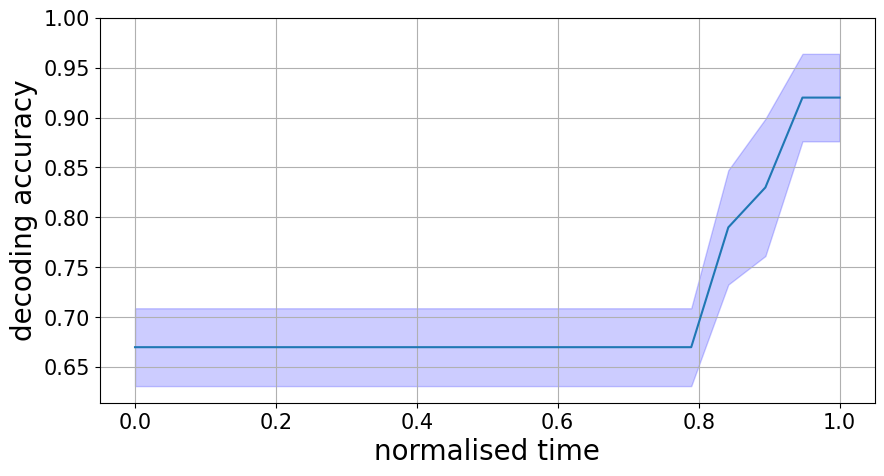

In [55]:
%matplotlib inline
# Plot mean accuracy with error bars
plt.figure(figsize=(10, 5))
plt.plot(np.linspace(0, 1, 20), mean_scores)
plt.fill_between(np.linspace(0, 1, 20),
                 mean_scores - std_error,
                 mean_scores + std_error,
                 color="b", alpha=0.2)
plt.xlabel("normalised time", fontsize=20)
plt.ylabel("decoding accuracy", fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylim(top=1)
plt.grid(True)

plt.show()

## for ventral turn

In [49]:
data.behaviour_names

{0: 'Dorsal turn',
 1: 'Forward',
 2: 'No state',
 3: 'Reverse-1',
 4: 'Reverse-2',
 5: 'Sustained reversal',
 6: 'Slowing',
 7: 'Ventral turn'}

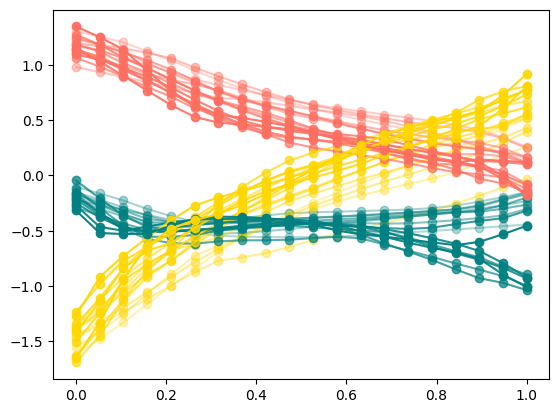

In [50]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

algorithm = 'BunDLeNet'
worm_num = 0

file_pattern = f'data/generated/embeddings/c_elegans/{{}}__{algorithm}_worm_{worm_num}'
Y0_tr = np.loadtxt(file_pattern.format('Y0_tr'))
Y1_tr = np.loadtxt(file_pattern.format('Y1_tr'))
Y0_tst = np.loadtxt(file_pattern.format('Y0_tst'))
Y1_tst = np.loadtxt(file_pattern.format('Y1_tst'))
B_train_1 = np.loadtxt(file_pattern.format('B_train_1')).astype(int)
B_test_1 = np.loadtxt(file_pattern.format('B_test_1')).astype(int)


bout_indices, next_b, _ = extract_bouts(B_train_1, b=7) # 7: 'Ventral turn'}
Y_bouts = [Y0_tr[idx] for idx in bout_indices]
Y_bouts = interpolate_bouts(Y_bouts, t_steps_interp=20, show_plot=True)

# Define the classifier
clf = LogisticRegression()
n_folds = 5
scores = np.zeros((Y_bouts.shape[2], n_folds))

for t in range(Y_bouts.shape[2]):
    Y_bout_t = Y_bouts[:, :, t]
    scores[t] = cross_val_score(clf, Y_bout_t, next_b, cv=n_folds, scoring='accuracy')

mean_scores = scores.mean(axis=1)
std_error = scores.std(axis=1) / np.sqrt(n_folds)  # Standard error of the mean


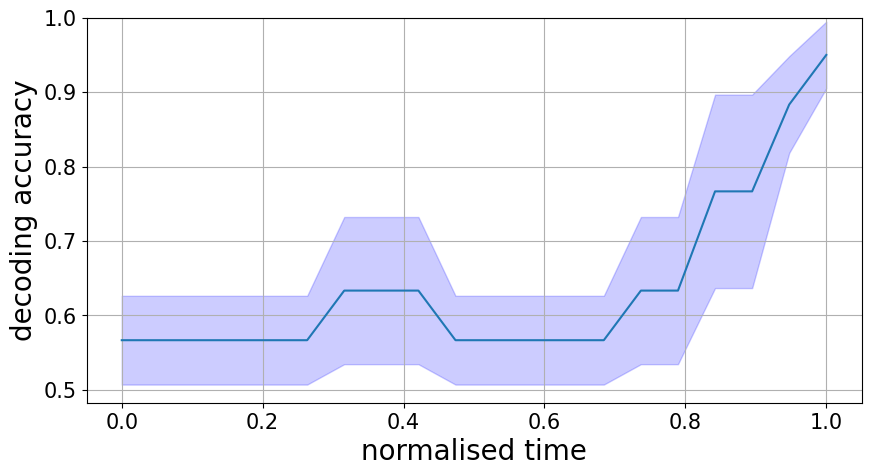

In [52]:
%matplotlib inline
# Plot mean accuracy with error bars
plt.figure(figsize=(10, 5))
plt.plot(np.linspace(0, 1, 20), mean_scores)
plt.fill_between(np.linspace(0, 1, 20),
                 mean_scores - std_error,
                 mean_scores + std_error,
                 color="b", alpha=0.2)
plt.xlabel("normalised time", fontsize=20)
plt.ylabel("decoding accuracy", fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylim(top=1)
plt.grid(True)

plt.show()